In [1]:
!pip install torchtext==0.16.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.4/755.4 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.4/184.4 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 111.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Import all the necessary modules

In [2]:
import pandas as pd
import nltk
import torch
from torchtext.vocab import build_vocab_from_iterator
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import Vocab
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import numpy
from sklearn.metrics import precision_score, recall_score, f1_score
from scipy.stats import spearmanr


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

# Question-1

In [4]:
#loading the datset
data = pd.read_csv("/content/Reviews 2.csv", on_bad_lines='skip', engine='python', quotechar='"')

data = data[['Text', 'Score']].dropna()

In [5]:
data.head()

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


preprocessing the data using NLTK

In [6]:
nltk.download('punkt',force='True')
nltk.download('stopwords',force='True')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [7]:
from nltk.corpus import stopwords
stop_words=set(stopwords.words('english'))

In [8]:
#tokenizing the data

def review_processing(text):
  text=text.lower()
  words = nltk.word_tokenize(text)

  cleaned_words=[]

  for i in words:

    if i.isalpha():
      if i not in stop_words:
        cleaned_words.append(i)

  return cleaned_words

In [9]:
#adding the tokens back into the dataset
processed_reviews =[]

for review in data['Text']:
  processed_reviews.append(review_processing(review))

data['tokens'] = processed_reviews

In [10]:
print(data.head())

                                                Text  Score  \
0  I have bought several of the Vitality canned d...      5   
1  Product arrived labeled as Jumbo Salted Peanut...      1   
2  This is a confection that has been around a fe...      4   
3  If you are looking for the secret ingredient i...      2   
4  Great taffy at a great price.  There was a wid...      5   

                                              tokens  
0  [bought, several, vitality, canned, dog, food,...  
1  [product, arrived, labeled, jumbo, salted, pea...  
2  [confection, around, centuries, light, pillowy...  
3  [looking, secret, ingredient, robitussin, beli...  
4  [great, taffy, great, price, wide, assortment,...  


In [11]:
vocabulory = build_vocab_from_iterator(data['tokens'],specials=["<unk>"])
vocabulory.set_default_index(vocabulory["<unk>"])

In [12]:
data['sequence'] = data['tokens'].apply(lambda x: vocabulory(x))

In [13]:
data.head()

,Text,Score,tokens,sequence
0,I have bought several of the Vitality canned d...,5,"[bought, several, vitality, canned, dog, food,...","[46, 210, 5331, 416, 32, 13, 122, 41, 3, 96, 9..."
1,Product arrived labeled as Jumbo Salted Peanut...,1,"[product, arrived, labeled, jumbo, salted, pea...","[9, 238, 1916, 5505, 1662, 875, 875, 143, 90, ..."
2,This is a confection that has been around a fe...,4,"[confection, around, centuries, light, pillowy...","[4973, 179, 7438, 232, 20060, 1786, 2762, 329,..."
3,If you are looking for the secret ingredient i...,2,"[looking, secret, ingredient, robitussin, beli...","[140, 2490, 471, 17583, 375, 41, 63, 676, 1306..."
4,Great taffy at a great price. There was a wid...,5,"[great, taffy, great, price, wide, assortment,...","[6, 2909, 6, 27, 1877, 2242, 431, 2909, 581, 3..."


In [14]:
print(len(vocabulory))

44189


# Question 2

In [15]:
print(data['Score'])

0        5
1        1
2        4
3        2
4        5
        ..
75160    5
75161    1
75162    2
75163    2
75164    5
Name: Score, Length: 75165, dtype: int64


In [16]:
ratings_count = data['Score'].value_counts().sort_index()

In [17]:
print(ratings_count)

Score
1     7063
2     4163
3     6020
4    11004
5    46915
Name: count, dtype: int64


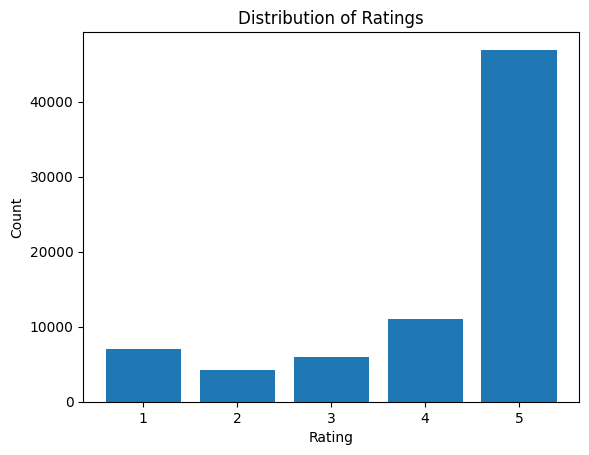

In [18]:
plt.bar(ratings_count.index, ratings_count.values)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Distribution of Ratings')
plt.show()

In [19]:
train_set = data[:int(0.7*len(data))]
val_set = data[int(0.7*len(data)):int(0.7*len(data))+int(0.15*len(data))]
test_set = data[int(0.7*len(data))+int(0.15*len(data)):]
print(len(train_set),len(val_set),len(test_set))

52615 11274 11276


In [37]:
#padding the sequence
''' If we increase the Max sequence length then we might have underfitting'''

MAX_SEQUENCE_LENGTH = 128
def truncate(seq):
    return seq[:MAX_SEQUENCE_LENGTH]

data['sequence'] = data['sequence'].apply(truncate)
PAD_TOKEN = 0
def sequence_padding(col,MAX_SEQUENCE_LENGTH = 128):
  col = torch.tensor(col,dtype=torch.long) if not isinstance(col,torch.Tensor) else col
  if len(col) < MAX_SEQUENCE_LENGTH:
    col = torch.cat([col,torch.full((MAX_SEQUENCE_LENGTH-len(col),),PAD_TOKEN,dtype = torch.long)])
  else:
    col = col[:MAX_SEQUENCE_LENGTH]
  return col

In [38]:
padded_train = [(label, sequence_padding(text)) for label, text in zip(train_set['Score'], train_set['sequence'])]
padded_val = [(label, sequence_padding(text)) for label, text in zip(val_set['Score'], val_set['sequence'])]
padded_test = [(label, sequence_padding(text)) for label, text in zip(test_set['Score'], test_set['sequence'])]

In [39]:
print(padded_train[0])

(5, tensor([  46,  210, 5331,  416,   32,   13,  122,   41,    3,   96,    9,  491,
           2, 2785, 1060,  350,  486,   31, 5228, 1771, 7819,    9,   31,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0]))


In [40]:
print(padded_val[0])

(5, tensor([ 182,  508, 1257,  843,  208,    1,  150,  181,  790,  508,    1,   55,
           2,  127, 1046,   17,  508, 4190,   73,    3,  508,   61,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0]))


In [41]:
print(padded_test[0])

(4, tensor([   6,    9,  117,  981,   18,   90,  447, 1091,  373, 2032,  770, 3867,
        1081,    5, 1066,    3,  174, 3713,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0]))


In [42]:
all_labels = {label for label, _ in padded_train}| \
 {label for label, _ in padded_val}| \
 {label for label, _ in padded_test}

print("Labels",all_labels)

Labels {1, 2, 3, 4, 5}


But torch reads the the labels as {0,1,2,3,4}

So we will be subtracting one from each label

In [43]:
def label_encoder(label):
  label-=1
  return label

padded_test = [(label_encoder(label),text) for label, text in padded_test]
padded_train = [(label_encoder(label),text) for label, text in padded_train]
padded_val = [(label_encoder(label),text) for label, text in padded_val]

In [44]:
all_labels = {label for label, _ in padded_train}| \
 {label for label, _ in padded_val}| \
 {label for label, _ in padded_test}

print("Updated Labels",all_labels)

Updated Labels {0, 1, 2, 3, 4}


# Question 3

Should be considered as a Classification task as we are predicting which class we will be falling in range of (1,2,3,4,5)

In [56]:
'''embedded dimensions and hidden demensions less than the below considered,
 were making the loss constant(not converging)'''
embedded_dims = 256
hidden_dims = 512
num_classes = 5
vocabulory_size = len(vocabulory)

In [67]:
class GRUCell(nn.Module):

  def __init__(self,vocabulory_size,embedded_dims,hidden_dims,num_classes,drop_rate=0.1):
    super(GRUCell,self).__init__()
    self.embeddings = nn.Embedding(vocabulory_size,embedded_dims,padding_idx=0)
    self.hidden_dims = hidden_dims
    self.drop_rate = nn.Dropout(drop_rate)
    #two gru cells (single cell was underfitting)
    self.gru_cell1 = nn.GRUCell(embedded_dims,hidden_dims)
    self.gru_cell2 = nn.GRUCell(hidden_dims,hidden_dims)
    self.fc = nn.Linear(hidden_dims,num_classes)

  def forward(self,x):

    embedded = self.embeddings(x)
    batch_size = x.size(0)
    hidden_state_1 = torch.zeros(batch_size,self.hidden_dims).to(x.device)
    hidden_state_2 = torch.zeros(batch_size,self.hidden_dims).to(x.device)
    for step_input in embedded.unbind(dim=1):
      hidden_state_1 = self.gru_cell1(step_input,hidden_state_1)
      hidden_state_2 = self.gru_cell2(hidden_state_1,hidden_state_2)
    hidden_state_2 = self.drop_rate(hidden_state_2)
    output = self.fc(hidden_state_2)
    return output

In [58]:
model = GRUCell(vocabulory_size,embedded_dims,hidden_dims,num_classes)

# Question 4

In [59]:
print(model)

GRUCell(
  (embeddings): Embedding(44189, 256, padding_idx=0)
  (drop_rate): Dropout(p=0.1, inplace=False)
  (gru_cell1): GRUCell(256, 512)
  (gru_cell2): GRUCell(512, 512)
  (fc): Linear(in_features=512, out_features=5, bias=True)
)


In [122]:
#model summary
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

embedding.weight torch.Size([44189, 64])
gru.weight_ih_l0 torch.Size([384, 64])
gru.weight_hh_l0 torch.Size([384, 128])
gru.bias_ih_l0 torch.Size([384])
gru.bias_hh_l0 torch.Size([384])
gru.weight_ih_l1 torch.Size([384, 128])
gru.weight_hh_l1 torch.Size([384, 128])
gru.bias_ih_l1 torch.Size([384])
gru.bias_hh_l1 torch.Size([384])
fc.weight torch.Size([5, 128])
fc.bias torch.Size([5])


In [60]:
#number of parameters
def num_of_parameters(model):
  params=0
  for param in model.parameters():
    if param.requires_grad:
      params+=param.numel()
  return params

print("Total trainable parameters are",num_of_parameters(model))

Total trainable parameters are 14073605


The loss function will be the Categorical Cross Entropy, because we are performing a classification task

In [61]:
loss_function = nn.CrossEntropyLoss()

# Question 5

In [62]:
#creating the dataloaders to start training the model
def create_dataloader(padded_data,batch_size):
  labels = torch.tensor([label for label, _ in padded_data],dtype = torch.long)
  texts = torch.stack([text for _, text in padded_data])
  dataset = TensorDataset(texts,labels)
  dataloader = DataLoader(dataset,batch_size=batch_size,shuffle=True)
  return dataloader

train_set_dataloader = create_dataloader(padded_train,batch_size=64)
val_set_dataloader = create_dataloader(padded_val,batch_size=64)
test_set_dataloader = create_dataloader(padded_test,batch_size=64)

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [64]:
optimizer = optim.Adam(model.parameters(),lr=0.001,weight_decay=0.0001)

In [65]:
#training of the model
epochs=15
def model_training(model,train_set_dataloader,val_set_dataloader,epochs=10):
  model.train()
  training_loss,validation_loss =[],[]
  for epoch in range(epochs):
    total_training_loss =0
    model.train()

    for batch_x, batch_y in train_set_dataloader:
      batch_x,batch_y = batch_x.long().to(device),batch_y.long().to(device)
      optimizer.zero_grad()
      outputs = model(batch_x)
      loss = loss_function(outputs,batch_y)
      loss.backward()
      optimizer.step()
      total_training_loss+=loss.item()

    model.eval()
    total_validation_loss =0
    with torch.no_grad():
      for batch_x, batch_y in val_set_dataloader:
        batch_x,batch_y = batch_x.long().to(device),batch_y.long().to(device)
        outputs = model(batch_x)
        loss = loss_function(outputs,batch_y)
        total_validation_loss+=loss.item()

    training_loss.append(total_training_loss/len(train_set_dataloader))
    validation_loss.append(total_validation_loss/len(val_set_dataloader))

    print(f"{epoch +1} Epochs out of {epochs}, Training Loss: {training_loss[-1]:.4f}, Validation Loss: {validation_loss[-1]:.4f}")

  plt.figure(figsize=(10,5))
  plt.plot(range(1,epochs+1),training_loss,label="Training Loss")
  plt.plot(range(1,epochs+1),validation_loss,label="Validation Loss")
  plt.xlabel("Epochs")
  plt.ylabel("loss")
  plt.title("Training and Validation Loss")
  plt.legend()
  plt.show()



1 Epochs out of 15, Training Loss: 1.1666, Validation Loss: 1.1154
2 Epochs out of 15, Training Loss: 1.0139, Validation Loss: 0.9189
3 Epochs out of 15, Training Loss: 0.8702, Validation Loss: 0.9311
4 Epochs out of 15, Training Loss: 0.7997, Validation Loss: 0.8125
5 Epochs out of 15, Training Loss: 0.7532, Validation Loss: 0.8018
6 Epochs out of 15, Training Loss: 0.7131, Validation Loss: 0.7852
7 Epochs out of 15, Training Loss: 0.6767, Validation Loss: 0.7792
8 Epochs out of 15, Training Loss: 0.6361, Validation Loss: 0.8015
9 Epochs out of 15, Training Loss: 0.5906, Validation Loss: 0.8281
10 Epochs out of 15, Training Loss: 0.5418, Validation Loss: 0.8470
11 Epochs out of 15, Training Loss: 0.4918, Validation Loss: 0.9007
12 Epochs out of 15, Training Loss: 0.4331, Validation Loss: 0.9617
13 Epochs out of 15, Training Loss: 0.3870, Validation Loss: 1.0054
14 Epochs out of 15, Training Loss: 0.3335, Validation Loss: 1.0597
15 Epochs out of 15, Training Loss: 0.2938, Validation Lo

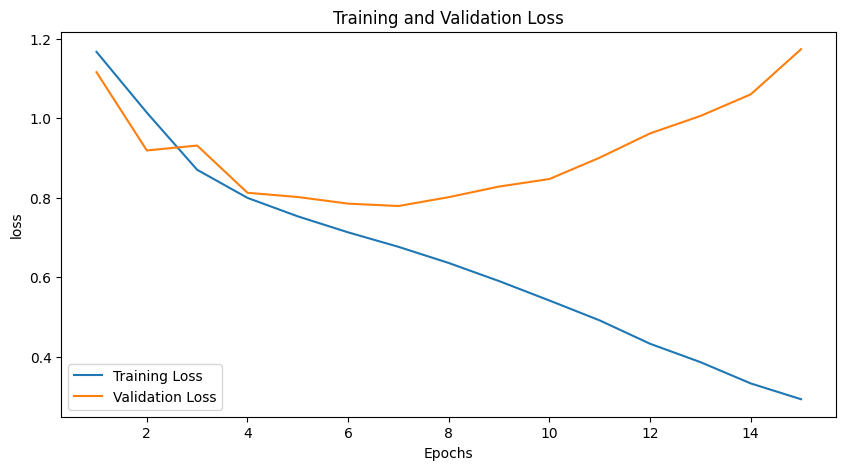

In [66]:
model.to(device)
model_training(model,train_set_dataloader,val_set_dataloader,epochs)

# Question 6

In [103]:
model.eval()
preds=[]
targets=[]
with torch.no_grad():
  for inp,out in test_set_dataloader:
    inp = inp.to(device)
    out = out.to(device)
    outputs = model(inp)
    prediction = torch.argmax(outputs,dim=1)
    preds.extend(prediction.cpu().tolist())
    targets.extend(out.cpu().tolist())

In [104]:
precision_value = precision_score(targets, preds, average="weighted", zero_division=0)
recall = recall_score(targets, preds, average="weighted", zero_division=0)
f1 = f1_score(targets, preds, average="weighted", zero_division=0)

print(f"Precision of GRU cell: {precision_value:.4f}")
print(f"Recall of GRU cell: {recall:.4f}")
print(f"F1 Score of GRU cell: {f1:.4f}")

Precision of GRU cell: 0.6672
Recall of GRU cell: 0.6850
F1 Score of GRU cell: 0.6729


We have subtracted 1 from all our ratings

No we are adding them back

In [70]:
for i in range(len(preds)):
  preds[i]+=1
  targets[i]+=1

calculation of the spearman's rank correlation coefficient

In [93]:
srcc,i = spearmanr(preds,targets)
print(f"Spearman's rank correlation coefficient of GRU cell: {srcc:.4f}")

Spearman's rank correlation coefficient of GRU cell: 0.6228


# Question 7

In [109]:
embedded_dims = 64
hidden_dims = 128
num_classes = 5
vocabulory_size = len(vocabulory)

In [110]:
class GRU(nn.Module):
  def __init__(self,vocabulory_size,embedded_dims,hidden_dims,num_classes,num_layers=2,drop_rate=0.3):
    super().__init__()

    self.embedding = nn.Embedding(vocabulory_size,embedded_dims,padding_idx=0)
    self.gru = nn.GRU(embedded_dims,hidden_dims,num_layers=num_layers,batch_first=True,dropout=drop_rate)
    self.fc = nn.Linear(hidden_dims,num_classes)

  def forward(self,x):
    embedded = self.embedding(x)

    _, hidden = self.gru(embedded)

    final_hidden = hidden[-1]

    output = self.fc(final_hidden)

    return output

In [111]:
model_gru = GRU(vocabulory_size,embedded_dims,hidden_dims,num_classes,num_layers=2,drop_rate=0.3)

In [112]:
print(model_gru)

GRU(
  (embedding): Embedding(44189, 64, padding_idx=0)
  (gru): GRU(64, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=5, bias=True)
)


In [113]:
model = model_gru.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [114]:
epochs = 5 #more number of epochs is making the model overfit

train_losses_gru = []
val_losses_gru = []

for epoch in range(epochs):

    model_gru.train()
    train_loss = 0

    for inputs, targets in train_set_dataloader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model_gru(inputs)
        loss = loss_function(outputs, targets)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_set_dataloader)


    model_gru.eval()
    val_loss = 0

    with torch.no_grad():
        for inputs, targets in val_set_dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model_gru(inputs)
            loss = loss_function(outputs, targets)

            val_loss += loss.item()

    val_loss /= len(val_set_dataloader)

    train_losses_gru.append(train_loss)
    val_losses_gru.append(val_loss)

    print(f"{epoch+1} Epochs, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

1 Epochs, Train Loss: 1.1289, Val Loss: 1.0008
2 Epochs, Train Loss: 0.8975, Val Loss: 0.8576
3 Epochs, Train Loss: 0.7689, Val Loss: 0.8301
4 Epochs, Train Loss: 0.6862, Val Loss: 0.8274
5 Epochs, Train Loss: 0.6054, Val Loss: 0.8394


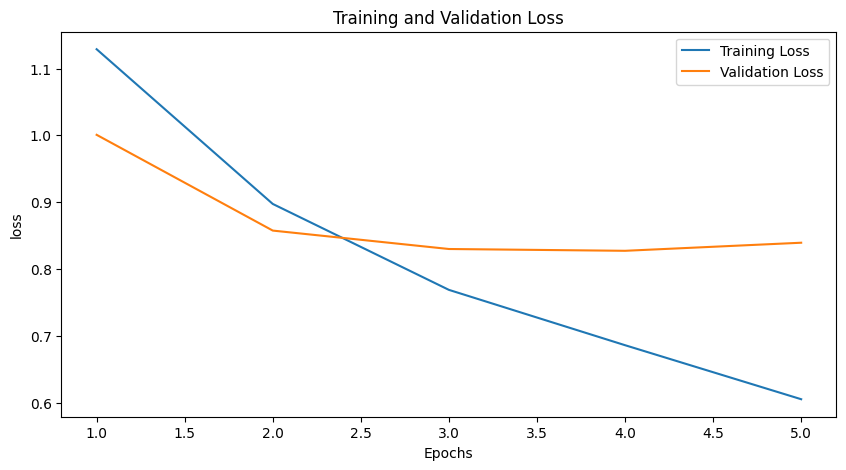

In [115]:
plt.figure(figsize=(10,5))
plt.plot(range(1,epochs+1),train_losses_gru,label="Training Loss")
plt.plot(range(1,epochs+1),val_losses_gru,label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [116]:
model_gru.eval()
preds_gru=[]
targets_gru=[]
with torch.no_grad():
  for inp,out in test_set_dataloader:
    inp = inp.to(device)
    out = out.to(device)
    outputs = model_gru(inp)
    prediction = torch.argmax(outputs,dim=1)
    preds_gru.extend(prediction.cpu().tolist())
    targets_gru.extend(out.cpu().tolist())

We have subtracted 1 from all our ratings

No we are adding them back

In [119]:
for i in range(len(preds_gru)):
    preds_gru[i] += 1
    targets_gru[i] += 1

In [120]:
srcc_gru, _ = spearmanr(preds_gru, targets_gru)

print(f"Spearman's rank correlation coefficient of GRU: {srcc_gru:.4f}")

Spearman's rank correlation coefficient of GRU: 0.6458
